## Prepare the dataset for training Latent Seq2Seq Model

In [2]:
import torch
import numpy as np
import pandas as pd
import json
from itertools import permutations
import os
from utils import b2dVAE

# 1. 初始化设置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_path = "models/m-vae-b2d.pth"
data_path = "data/data-1-vae.csv"
output_path = "data/data-2-s2s.json"

# 2. 加载模型
def load_model():
    model = b2dVAE().to(device)
    checkpoint = torch.load(vae_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

B2DVAE = load_model()

# 3. 数据加载与预处理
def load_data():
    df = pd.read_csv(data_path)
    points = df[['X', 'Y']].values
    energies = df['Potential_Energy'].values
    return points, energies

points, energies = load_data()

# 4. 编码函数（返回组合的潜空间表示）
def encode_point(model, point):
    with torch.no_grad():
        input_tensor = torch.FloatTensor(point).unsqueeze(0).to(device)
        mu, logvar = model.encode(input_tensor)
        # 组合mu和logvar作为潜空间表示（共16维）
        h = torch.cat([mu.squeeze(0), logvar.squeeze(0)]).cpu().numpy()
    return h

# 5. 编码所有点
print("正在编码所有点的潜空间表示...")
h_list = [encode_point(B2DVAE, point) for point in points]

# 6. 计算所有点对（双向）
def compute_all_pairs(points, energies, h_list):
    n = len(points)
    pairs = []
    
    # 使用排列生成所有有序点对（包括i->j和j->i）
    for i, j in permutations(range(n), 2):
        # 计算ΔX和ΔY
        delta_x = points[j][0] - points[i][0]
        delta_y = points[j][1] - points[i][1]
        
        # 构建路径字典
        path = {
            "input": {
                "delta_x": float(delta_x),
                "delta_y": float(delta_y),
                "energy": float(energies[i]),
                "h": h_list[i].tolist()
            },
            "output": {
                "energy": float(energies[j]),
                "h": h_list[j].tolist()
            },
            "metadata": {
                "source_idx": i,
                "target_idx": j
            }
        }
        pairs.append(path)
    
    return pairs

print("正在计算所有点对路径...")
all_pairs = compute_all_pairs(points, energies, h_list)

# 7. 保存结果
os.makedirs("data", exist_ok=True)
with open(output_path, 'w') as f:
    json.dump(all_pairs, f, indent=2)

print(f"共生成 {len(all_pairs)} 条双向路径数据")
print(f"已保存到 {output_path}")
print("数据结构示例：")
print(json.dumps(all_pairs[0], indent=2))

正在编码所有点的潜空间表示...
正在计算所有点对路径...
共生成 999000 条双向路径数据
已保存到 data/data-2-s2s.json
数据结构示例：
{
  "input": {
    "delta_x": 4.609393,
    "delta_y": 2.140608,
    "energy": -2.324661,
    "h": [
      0.03135908395051956,
      -0.0005664657801389694,
      -0.01170949637889862,
      -1.0634005069732666,
      -0.0018706023693084717,
      -0.04514835774898529,
      0.06783656030893326,
      -0.009525146335363388,
      -0.031369466334581375,
      -0.025819942355155945,
      -0.03396562486886978,
      -2.4191956520080566,
      0.013757258653640747,
      -0.005048759281635284,
      -3.235098123550415,
      -0.00048738718032836914
    ]
  },
  "output": {
    "energy": -0.018615,
    "h": [
      0.013950027525424957,
      0.042673468589782715,
      0.00018231570720672607,
      0.6290959715843201,
      0.048873916268348694,
      -0.01022423803806305,
      1.5104997158050537,
      0.002115577459335327,
      0.01651381328701973,
      0.05882127583026886,
      0.004354529082775116

# Pair distance dirstribution

Constructing Matric: 100%|██████████| 9990/9990 [00:00<00:00, 840004.35it/s]


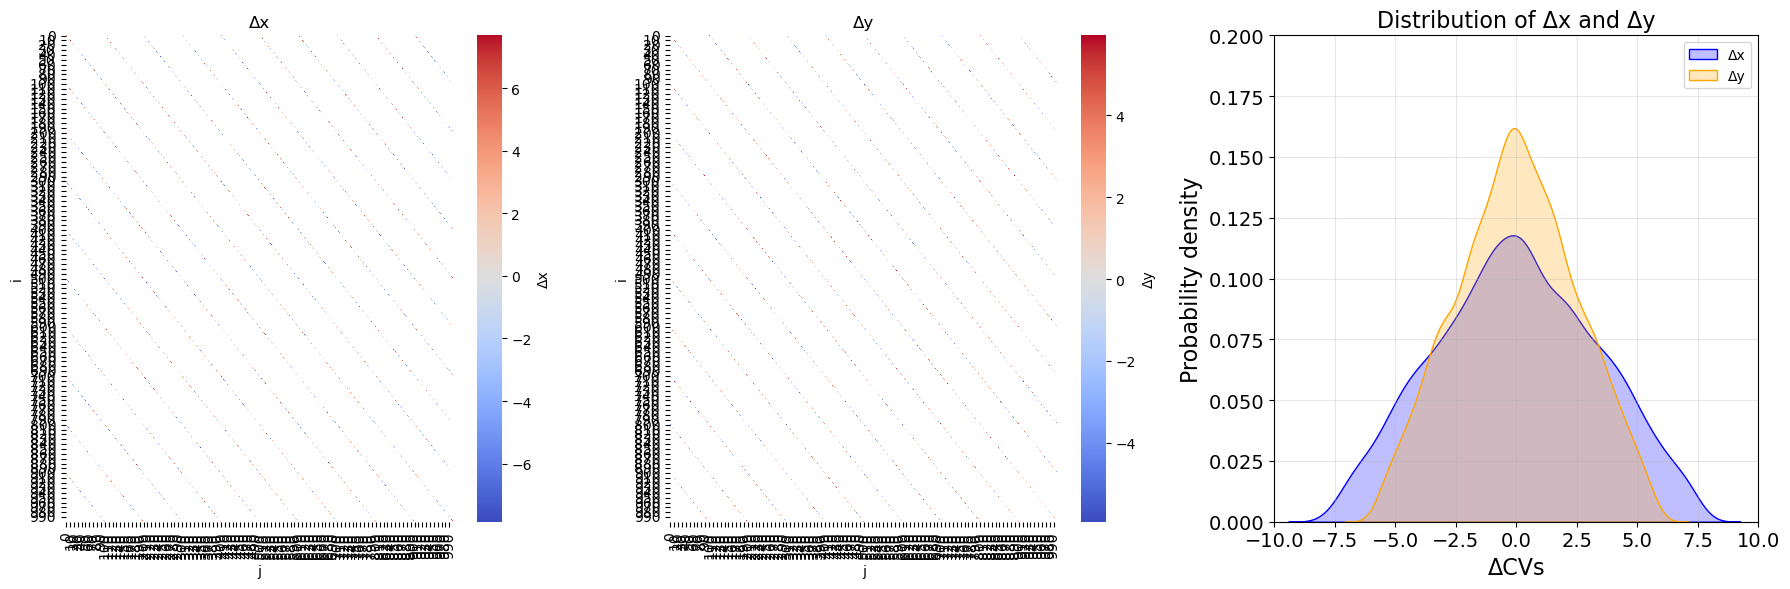

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def load_sampled_data(file_path, sample_interval=10):
    with open(file_path, 'r') as f:
        full_data = json.load(f)
    return full_data[::sample_interval]

sampled_data = load_sampled_data("data/data-2-s2s.json", 100)

max_idx = max(max(item['metadata']['source_idx'], item['metadata']['target_idx']) 
              for item in sampled_data) + 1

delta_x_matrix = np.full((max_idx, max_idx), np.nan)
delta_y_matrix = np.full((max_idx, max_idx), np.nan)

for item in tqdm(sampled_data, desc="Constructing Matric"):
    i = item['metadata']['source_idx']
    j = item['metadata']['target_idx']
    delta_x_matrix[i,j] = item['input']['delta_x']
    delta_y_matrix[i,j] = item['input']['delta_y']

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.heatmap(delta_x_matrix, cmap="coolwarm", center=0,
            xticklabels=10, yticklabels=10,
            cbar_kws={'label': 'Δx'})
plt.title('Δx')
plt.xlabel('j')
plt.ylabel('i')

# 7. Δy热力图
plt.subplot(1, 3, 2)
sns.heatmap(delta_y_matrix, cmap="coolwarm", center=0,
            xticklabels=10, yticklabels=10,
            cbar_kws={'label': 'Δy'})
plt.title('Δy')
plt.xlabel('j')
plt.ylabel('i')

plt.subplot(1, 3, 3)
sns.kdeplot([x for x in delta_x_matrix.flatten() if not np.isnan(x)], 
            label='Δx', fill=True, color='blue')
sns.kdeplot([y for y in delta_y_matrix.flatten() if not np.isnan(y)], 
            label='Δy', fill=True, color='orange')
plt.title('Distribution of Δx and Δy', fontsize = 16)
plt.xlabel('ΔCVs', fontsize = 16)
plt.ylabel('Probability density', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim(-10,10)
plt.ylim(0,0.2)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/delta_analysis.tiff", dpi=300, bbox_inches='tight')
plt.show()

# # 9. 统计信息输出
# valid_dx = [x for x in delta_x_matrix.flatten() if not np.isnan(x)]
# valid_dy = [y for y in delta_y_matrix.flatten() if not np.isnan(y)]

# print("\n统计摘要:")
# print(f"Δx - 均值: {np.mean(valid_dx):.4f} 标准差: {np.std(valid_dx):.4f}")
# print(f"Δy - 均值: {np.mean(valid_dy):.4f} 标准差: {np.std(valid_dy):.4f}")
# print(f"Δx范围: [{min(valid_dx):.4f}, {max(valid_dx):.4f}]")
# print(f"Δy范围: [{min(valid_dy):.4f}, {max(valid_dy):.4f}]")